In [1]:
from argparse import Namespace
from pathlib import Path
import sys

from IPython.display import display
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import torch

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.build import build_dataset, build_loader, load_config_defaults, load_predictor
from src.predict.sds.sa import compute_surface_area
from src.predict.sds.tpc import compute_tpc
from src.predict.sds.vf import compute_volume_fraction
from src.predict.types import AnchorSlice, PredictOptions


def to_phase_image(sample, num_phases):
    image = sample.detach().cpu()[0].clamp(-1.0, 1.0)
    image = ((image + 1.0) * 0.5 * (num_phases - 1)).round()
    return image.numpy().astype(np.uint8)


def phase_values(images, num_phases):
    array = np.asarray(images, dtype=np.float32)
    array = array / (num_phases - 1) * 2.0 - 1.0
    return torch.from_numpy(array.copy()).float()


In [2]:
RUN_DIR = None
SCALE_SIZE = 192
TARGET_IMAGE_COUNT = 16
SAMPLE_IMAGE = ROOT / "data" / "sample.png"

run_dir = Path(RUN_DIR) if RUN_DIR else max(
    [p for p in (ROOT / "run").glob("*") if (p / "diffusion.yaml").is_file()],
    key=lambda p: p.stat().st_mtime,
)
run_dir = run_dir if run_dir.is_absolute() else ROOT / run_dir

vae_defaults = load_config_defaults(run_dir / "vae.yaml")
ANCHOR_SIZE = int(vae_defaults["size"] if "size" in vae_defaults else vae_defaults["image_size"])
condition_start = (SCALE_SIZE - ANCHOR_SIZE) // 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
args = Namespace(**vae_defaults)
args.image_paths = [SAMPLE_IMAGE]
args.crop_size = ANCHOR_SIZE
args.size = ANCHOR_SIZE
args.batch_size = TARGET_IMAGE_COUNT + 1
args.augment = False

num_phases = args.num_phases
dataset = build_dataset(args)
batch = next(build_loader(dataset, args, device=torch.device("cpu")))
anchor_image = to_phase_image(batch[0], num_phases)
target_images = [to_phase_image(sample, num_phases) for sample in batch[1:]]
anchor = AnchorSlice(image=anchor_image, axis=0, index=ANCHOR_SIZE // 2)

print("sample:", SAMPLE_IMAGE)
print("run dir:", run_dir)
print("anchor size:", ANCHOR_SIZE, "scale size:", SCALE_SIZE, "condition start:", condition_start)
print("batch:", tuple(batch.shape), "anchor:", anchor_image.shape, "target images:", len(target_images))


sample: d:\code\microlad\data\sample.png
run dir: d:\code\microlad\run\20260628-091822-400207
anchor size: 64 scale size: 192 condition start: 64
batch: (17, 1, 64, 64) anchor: (64, 64) target images: 16


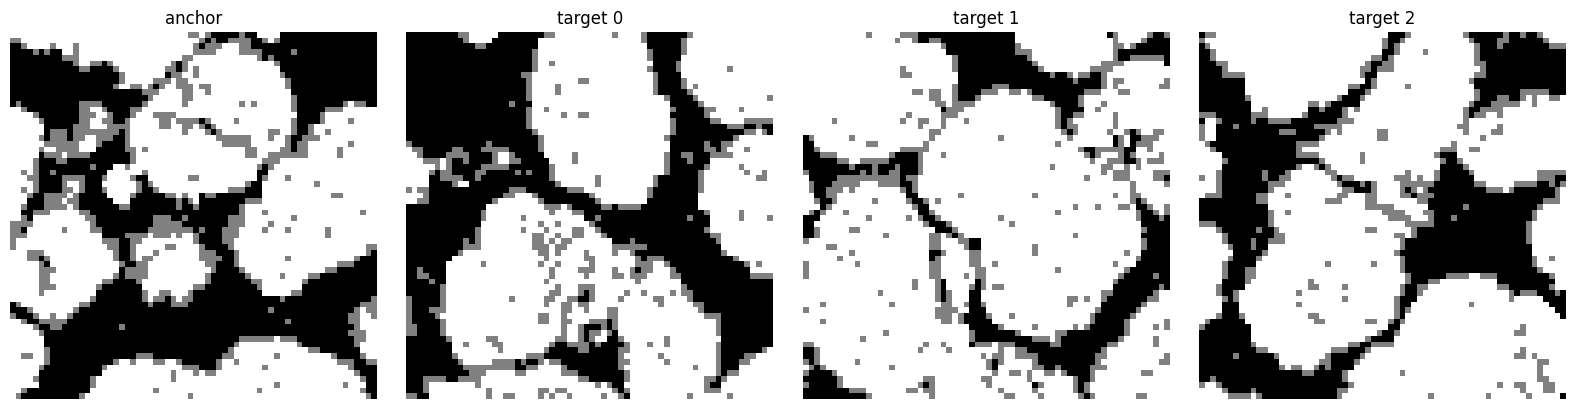

In [3]:
preview = [("anchor", anchor_image), ("target 0", target_images[0]), ("target 1", target_images[1]), ("target 2", target_images[2])]
fig, axes = plt.subplots(1, len(preview), figsize=(4 * len(preview), 4), squeeze=False)
for ax, (title, image) in zip(axes.ravel(), preview):
    ax.imshow(image, cmap="gray", vmin=0, vmax=num_phases - 1, interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()


In [4]:
options = PredictOptions(
    num_phases=num_phases,
    anchor_weight=1.0,
    sds_weight=1.0,
    sds_steps=12,
    sds_slice_steps=1,
    sds_lr=1.0e-2,
    vf_weight=1.0,
    tpc_weight=0.5,
    sa_weight=0.5,
    refine_steps=0,
)

predictor = load_predictor(run_dir, device=device)
volume, stats = predictor.predict(
    options,
    anchors=[anchor],
    target_images=target_images,
    volume_size=SCALE_SIZE,
)
volume_np = volume.detach().cpu().numpy()
stats = {key: float(value.detach().cpu()) for key, value in stats.items() if torch.is_tensor(value) and value.numel() == 1}
condition_start = int(stats.get("condition_start", condition_start))

print("volume:", volume_np.shape, "phases:", np.unique(volume_np).tolist())
print("condition start:", condition_start, "anchor output index:", condition_start + anchor.index)
print("stats:", stats)


volume: (192, 192, 192) phases: [0, 1, 2]
condition start: 64 anchor output index: 96
stats: {'sds': 0.03273172676563263, 'vf': 0.0022654111962765455, 'tpc': 0.0005426995339803398, 'sa': 0.00032700758310966194, 'anchor': 1.5672909021377563, 'loss': 0.0685187429189682, 'steps': 12.0}


metric       phase       target    generated          error
vf               0     0.254389     0.160368       0.094021
vf               1     0.135220     0.294347       0.159128
vf               2     0.610391     0.545284       0.065107
sa               0     0.103841     0.108255       0.004414
sa               1     0.101950     0.183984       0.082034
sa               2     0.143041     0.186226       0.043186
tpc              0      profile      profile   mae 0.049796
tpc              1      profile      profile   mae 0.073054
tpc              2      profile      profile   mae 0.081412


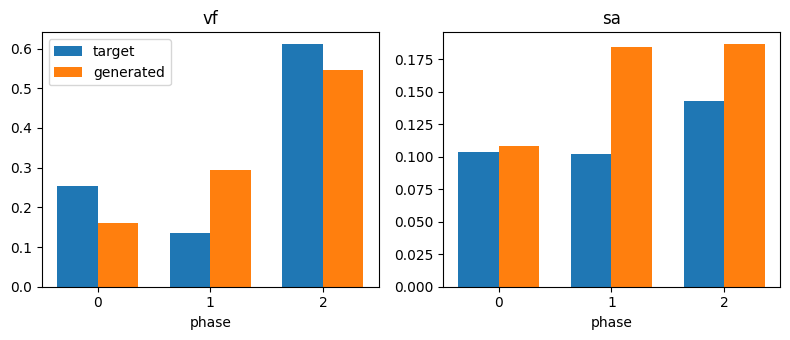

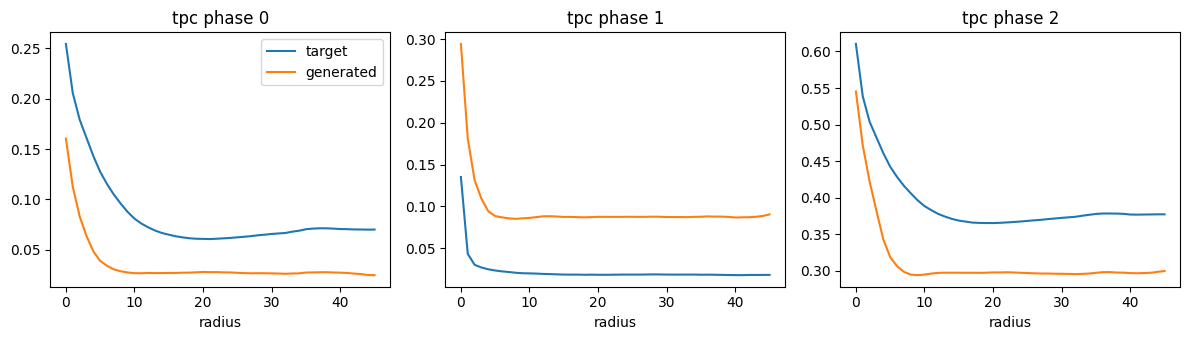

In [5]:
generated_images = [
    volume_np[z, condition_start : condition_start + ANCHOR_SIZE, condition_start : condition_start + ANCHOR_SIZE]
    for z in range(condition_start, condition_start + ANCHOR_SIZE)
]
target_values = phase_values(target_images, num_phases)
generated_values = phase_values(generated_images, num_phases)
rows = []
plots = []


def add_phase_metric(name, target, generated):
    target_np = target.detach().cpu().numpy()
    generated_np = generated.detach().cpu().numpy()
    diff_np = np.abs(generated_np - target_np)
    for phase, (target_value, generated_value, diff_value) in enumerate(zip(target_np, generated_np, diff_np)):
        rows.append((name, phase, f"{target_value:.6f}", f"{generated_value:.6f}", f"{diff_value:.6f}"))
    plots.append((name, target_np, generated_np))


with torch.no_grad():
    add_phase_metric(
        "vf",
        compute_volume_fraction(target_values, num_phases=num_phases),
        compute_volume_fraction(generated_values, num_phases=num_phases),
    )
    add_phase_metric(
        "sa",
        compute_surface_area(target_values, num_phases=num_phases),
        compute_surface_area(generated_values, num_phases=num_phases),
    )
    target_tpc = compute_tpc(target_values, num_phases=num_phases)
    generated_tpc = compute_tpc(generated_values, num_phases=num_phases)
    tpc_mae = (generated_tpc - target_tpc).abs().mean(dim=1).detach().cpu().numpy()
    for phase, value in enumerate(tpc_mae):
        rows.append(("tpc", phase, "profile", "profile", f"mae {value:.6f}"))

print(f"{'metric':<12} {'phase':>5} {'target':>12} {'generated':>12} {'error':>14}")
for name, phase, target_value, generated_value, error in rows:
    print(f"{name:<12} {phase:>5d} {target_value:>12} {generated_value:>12} {error:>14}")

fig, axes = plt.subplots(1, len(plots), figsize=(4 * len(plots), 3.5), squeeze=False)
x = np.arange(num_phases)
for ax, (name, target_np, generated_np) in zip(axes.ravel(), plots):
    ax.bar(x - 0.18, target_np, width=0.36, label="target")
    ax.bar(x + 0.18, generated_np, width=0.36, label="generated")
    ax.set_title(name)
    ax.set_xticks(x)
    ax.set_xlabel("phase")
axes.ravel()[0].legend()
plt.tight_layout()

fig, axes = plt.subplots(1, num_phases, figsize=(4 * num_phases, 3.5), squeeze=False)
target_tpc_np = target_tpc.detach().cpu().numpy()
generated_tpc_np = generated_tpc.detach().cpu().numpy()
for phase, ax in enumerate(axes.ravel()):
    ax.plot(target_tpc_np[phase], label="target")
    ax.plot(generated_tpc_np[phase], label="generated")
    ax.set_title(f"tpc phase {phase}")
    ax.set_xlabel("radius")
axes.ravel()[0].legend()
plt.tight_layout()


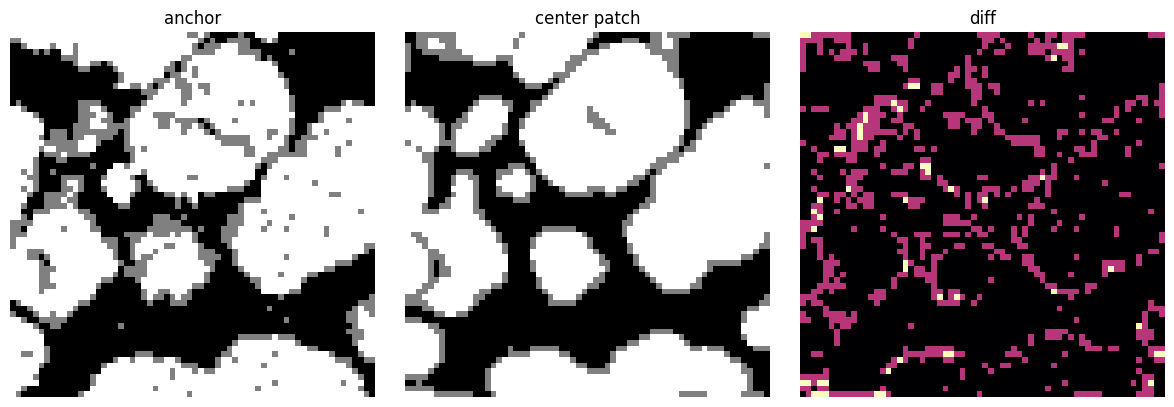

In [6]:
anchor_output_index = condition_start + anchor.index
center = volume_np[anchor_output_index]
center_patch = center[condition_start : condition_start + ANCHOR_SIZE, condition_start : condition_start + ANCHOR_SIZE]
diff = np.abs(center_patch.astype(np.int16) - anchor_image.astype(np.int16))
items = [("anchor", anchor_image, "gray", 0, num_phases - 1), ("center patch", center_patch, "gray", 0, num_phases - 1), ("diff", diff, "magma", 0, max(1, num_phases - 1))]

fig, axes = plt.subplots(1, 3, figsize=(12, 4), squeeze=False)
for ax, (title, image, cmap, vmin, vmax) in zip(axes.ravel(), items):
    ax.imshow(image, cmap=cmap, vmin=vmin, vmax=vmax, interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()


In [7]:
axis_picker = widgets.Dropdown(
    options=[("axis 0", 0), ("axis 1", 1), ("axis 2", 2)],
    value=anchor.axis,
    description="axis",
)
index_slider = widgets.IntSlider(
    value=condition_start + anchor.index,
    min=0,
    max=volume_np.shape[anchor.axis] - 1,
    step=1,
    description="index",
    continuous_update=True,
)
out = widgets.Output()


def take_slice(axis, index):
    if axis == 0:
        return volume_np[index]
    if axis == 1:
        return volume_np[:, index, :]
    return volume_np[:, :, index]


def update_index_range(change=None):
    index_slider.max = volume_np.shape[axis_picker.value] - 1
    index_slider.value = min(index_slider.value, index_slider.max)


def show_slice(change=None):
    axis = axis_picker.value
    index = index_slider.value
    with out:
        out.clear_output(wait=True)
        plt.figure(figsize=(5, 5))
        plt.imshow(take_slice(axis, index), cmap="gray", vmin=0, vmax=num_phases - 1, interpolation="nearest")
        plt.title(f"axis {axis}, index {index}")
        plt.axis("off")
        plt.show()


axis_picker.observe(update_index_range, names="value")
axis_picker.observe(show_slice, names="value")
index_slider.observe(show_slice, names="value")

display(widgets.HBox([axis_picker, index_slider]), out)
show_slice()


Output()